Philip Fowler
2025 17 07
A notebook to investigate methods for comparing different datasets

# Import Libraries

In [ ]:
# First, let us import a bunch of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import lag_plot
from scipy.optimize import linear_sum_assignment
from scipy.stats import ks_2samp, pearsonr
from scipy.signal import medfilt
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx
import h5py
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from matplotlib.backends.backend_pdf import PdfPages
import os
from reportlab.platypus import Image
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, PageBreak
from reportlab.rl_config import defaultPageSize
from reportlab.lib.units import inch
import warnings

warnings.filterwarnings('ignore')


In [59]:
# Define some constants
ground_truth = 'data/cGround_Truth_data_10trials_150stims_180000ms.hdf5'
submission = 'data/cNo_Inhibitory_Neurons_10trials_150stims_180000ms.hdf5'

In [60]:
for filename in [ground_truth, submission]:
    print(f"\nExamining file: {filename}")
    with h5py.File(filename, 'r') as f:
        print("Keys:", list(f.keys()))
        for key in f.keys():
            data_item = f[key]
            print(f"{key}: type={type(data_item)}", end='')
            if isinstance(data_item, h5py.Dataset):
                print(f", shape={data_item.shape}")
            else:
                print()



Examining file: data/cGround_Truth_data_10trials_150stims_180000ms.hdf5
Keys: ['trial_0', 'trial_1', 'trial_2', 'trial_3', 'trial_4', 'trial_5', 'trial_6', 'trial_7', 'trial_8', 'trial_9']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>
trial_2: type=<class 'h5py._hl.group.Group'>
trial_3: type=<class 'h5py._hl.group.Group'>
trial_4: type=<class 'h5py._hl.group.Group'>
trial_5: type=<class 'h5py._hl.group.Group'>
trial_6: type=<class 'h5py._hl.group.Group'>
trial_7: type=<class 'h5py._hl.group.Group'>
trial_8: type=<class 'h5py._hl.group.Group'>
trial_9: type=<class 'h5py._hl.group.Group'>

Examining file: data/cNo_Inhibitory_Neurons_10trials_150stims_180000ms.hdf5
Keys: ['trial_0', 'trial_1', 'trial_2', 'trial_3', 'trial_4', 'trial_5', 'trial_6', 'trial_7', 'trial_8', 'trial_9']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>
trial_2: type=<class 'h5py._hl.group.Group'>
trial_3: type=<class 'h5py._hl.

In [61]:
for filename in [ground_truth, submission]:
    print(f"\nExamining trial groups in file: {filename}")
    with h5py.File(filename, 'r') as f:
        for trial_name in f.keys():
            if 'trial' in trial_name.lower():
                trial_group = f[trial_name]
                if isinstance(trial_group, h5py.Group):
                    print(f"Keys in {trial_name} group:", list(trial_group.keys()))
                    for name, item in trial_group.items():
                        if isinstance(item, h5py.Dataset):
                            print(f"Dataset '{name}' in {trial_name} shape:", item.shape)
                        elif isinstance(item, h5py.Group):
                            print(f"'{name}' in {trial_name} is a group, not a dataset.")
                        else:
                            print(f"'{name}' in {trial_name} is not a group or dataset.")
                else:
                    print(f"{trial_name} is not a group, skipping.")



Examining trial groups in file: data/cGround_Truth_data_10trials_150stims_180000ms.hdf5
Keys in trial_0 group: ['data']
Dataset 'data' in trial_0 shape: (180000, 11)
Keys in trial_1 group: ['data']
Dataset 'data' in trial_1 shape: (180000, 11)
Keys in trial_2 group: ['data']
Dataset 'data' in trial_2 shape: (180000, 11)
Keys in trial_3 group: ['data']
Dataset 'data' in trial_3 shape: (180000, 11)
Keys in trial_4 group: ['data']
Dataset 'data' in trial_4 shape: (180000, 11)
Keys in trial_5 group: ['data']
Dataset 'data' in trial_5 shape: (180000, 11)
Keys in trial_6 group: ['data']
Dataset 'data' in trial_6 shape: (180000, 11)
Keys in trial_7 group: ['data']
Dataset 'data' in trial_7 shape: (180000, 11)
Keys in trial_8 group: ['data']
Dataset 'data' in trial_8 shape: (180000, 11)
Keys in trial_9 group: ['data']
Dataset 'data' in trial_9 shape: (180000, 11)

Examining trial groups in file: data/cNo_Inhibitory_Neurons_10trials_150stims_180000ms.hdf5
Keys in trial_0 group: ['data']
Datase

# Create dataframes/arrays for each trial

In [62]:
for fname, prefix in [(ground_truth, 'gt'), (submission, 'sub')]:
    with h5py.File(fname, 'r') as f:
        for trial_name in f.keys():
            if trial_name.startswith('trial_'):
                trial_group = f[trial_name]
                for name, item in trial_group.items():
                    if isinstance(item, h5py.Dataset):
                        data = item[()]
                        if data.ndim == 2:
                            columns = [f'neuron{i+1}' for i in range(data.shape[1])]
                            df = pd.DataFrame(data, columns=columns)
                        else:
                            df = pd.DataFrame(data)
                        # Rename columns
                        new_columns = ['time']
                        for i in range(1, (len(columns))//2 + 1):
                            new_columns.append(f'neuron{i}_spike')
                            new_columns.append(f'neuron{i}_mempot')
                        df.columns = new_columns[:df.shape[1]]
                        # Name dataframe according to file and trial
                        trial_idx = trial_name.split('_')[1]
                        globals()[f"{prefix}_trial{trial_idx}_df"] = df

In [63]:
# Automatically collect all gt and sub trial dataframes based on variable names
gt_trials = [globals()[name] for name in sorted(globals()) if name.startswith('gt_trial') and name.endswith('_df')]
sub_trials = [globals()[name] for name in sorted(globals()) if name.startswith('sub_trial') and name.endswith('_df')]
all_trials = gt_trials + sub_trials
spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]

NUM_GT_TRIALS = len(gt_trials)
NUM_SUB_TRIALS = len(sub_trials)
num_gt_neurons = len([col for col in gt_trials[0].columns if col.endswith('_spike')])
num_sub_neurons = len([col for col in sub_trials[0].columns if col.endswith('_spike')])

### Create Concatenated DataFrames for all trials

In [64]:
# For testing purposes, we can use a single trial dataframe
# Uncomment out the next two lines if you want to use all trials
# gt_concat_df = pd.concat(gt_trials, ignore_index=True)
# sub_concat_df = pd.concat(sub_trials, ignore_index=True)

# For testing purposes, we can use a single trial dataframe
# comment out the next two lines if you want to use all trials
gt_concat_df = gt_trial0_df
sub_concat_df = sub_trial0_df

### Find average firing rates

In [65]:
bin_size = 500  
def compute_psth(trials, spike_columns, bin_size):
    num_bins = trials[0].shape[0] // bin_size
    num_neurons = len(spike_columns)
    binned_spikes = np.zeros((len(trials), num_bins, num_neurons))
    for t, trial_df in enumerate(trials):
        for n, col in enumerate(spike_columns):
            spikes = trial_df[col].values[:num_bins * bin_size]
            binned_spikes[t, :, n] = spikes.reshape(num_bins, bin_size).sum(axis=1)
    mean_spikes = binned_spikes.mean(axis=0)
    firing_rate = mean_spikes / bin_size 
    return firing_rate

psth_gt = compute_psth(gt_trials, spike_columns, bin_size)
psth_sub = compute_psth(sub_trials, spike_columns, bin_size)
# note: These are numpy arrays not dataframes

In [66]:
gt_concat_df.shape, sub_concat_df.shape

((180000, 11), (180000, 11))

In [67]:
gt_trial0_df.shape, sub_trial0_df.shape


((180000, 11), (180000, 11))

In [68]:
psth_gt.shape, psth_sub.shape

((360, 5), (360, 5))

# Spike Rate Metrics
### These metrics use the concatenated dataframes

This raster plot is not perfect.  I shortened the length of the red lines so that the black were visible. 

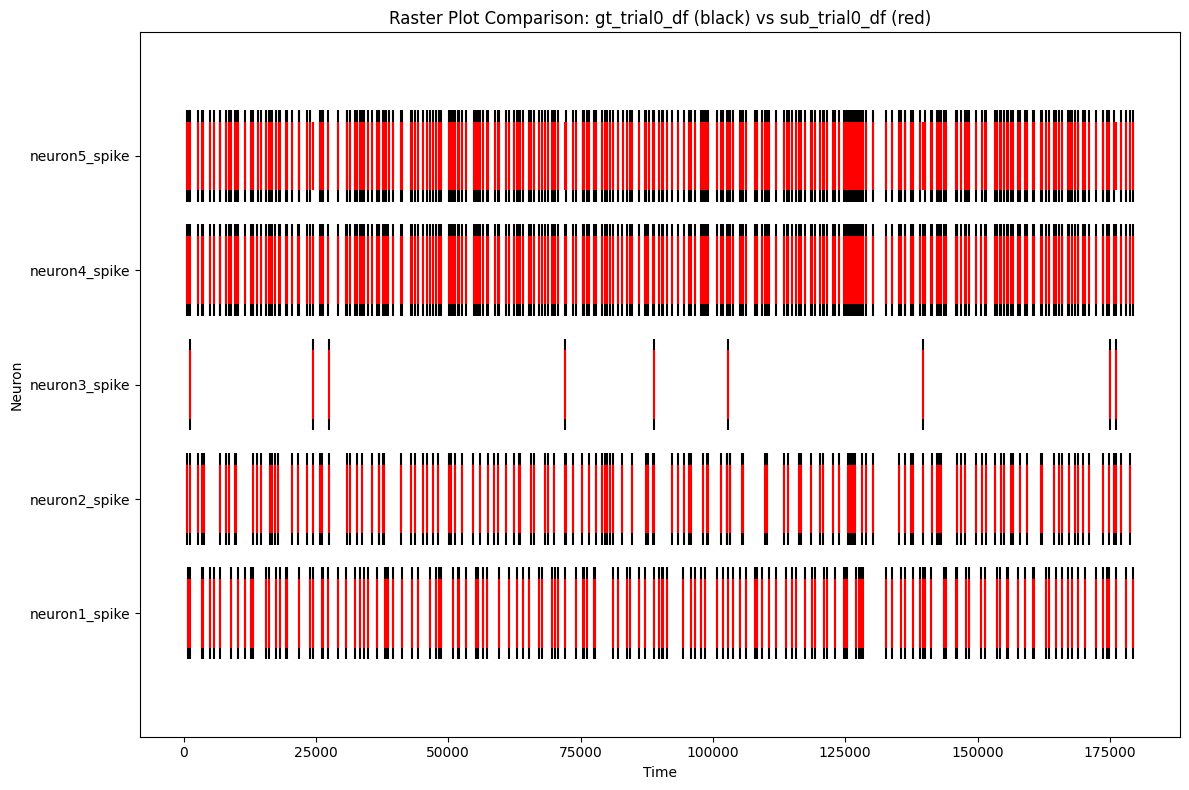

In [70]:
spike_columns = [col for col in gt_concat_df.columns if col.endswith('_spike')]
gt_spike_times_per_neuron = [gt_concat_df.index[gt_concat_df[col] == 1].to_numpy() for col in spike_columns]
sub_spike_times_per_neuron = [sub_concat_df.index[sub_concat_df[col] == 1].to_numpy() for col in spike_columns]

plt.figure(figsize=(12, 8))
plt.eventplot(gt_spike_times_per_neuron, orientation='horizontal', colors='black', linelengths=0.8, label='Ground Truth')
plt.eventplot(sub_spike_times_per_neuron, orientation='horizontal', colors='red', linelengths=0.6, label='Submission')
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot Comparison: gt_trial0_df (black) vs sub_trial0_df (red)')
plt.tight_layout()
plt.show()


This raster plot only plots the difference between the ground truth and the submission

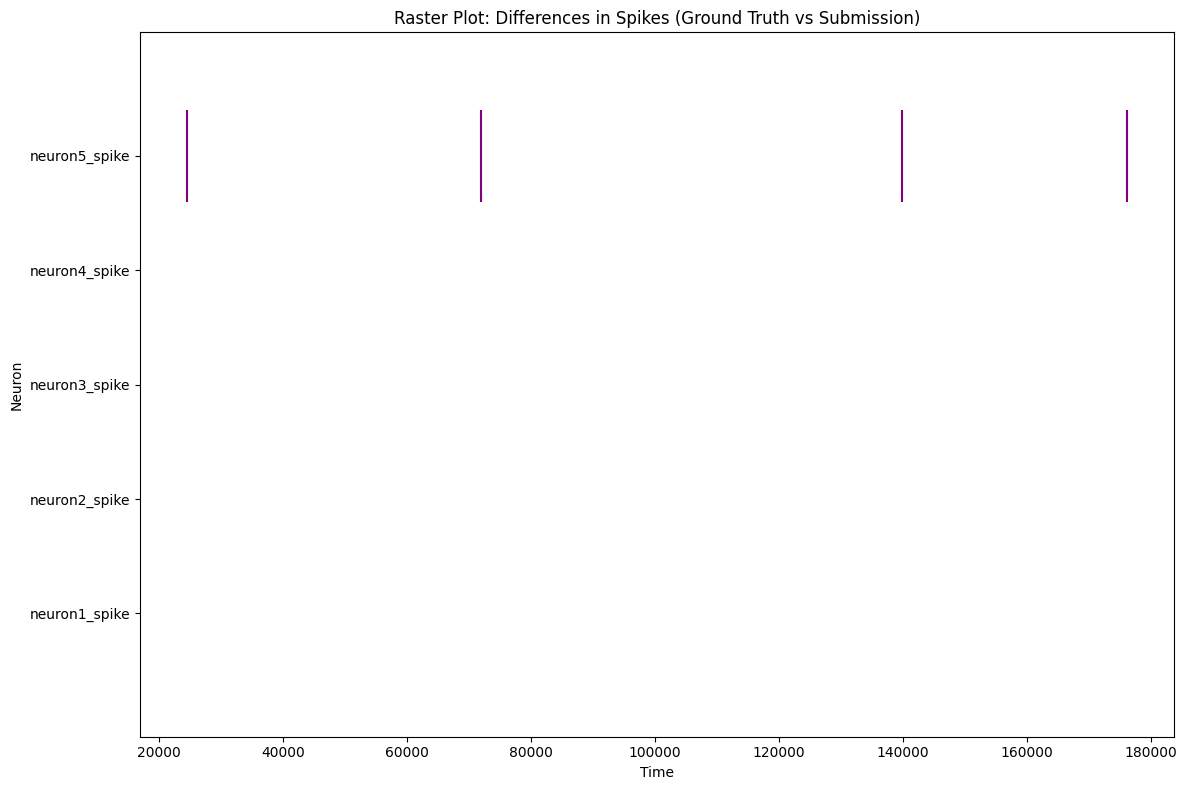

In [71]:
diff_spike_times_per_neuron = []
for gt_spikes, sub_spikes in zip(gt_spike_times_per_neuron, sub_spike_times_per_neuron):
    diff_times = np.setxor1d(gt_spikes, sub_spikes)
    diff_spike_times_per_neuron.append(diff_times)

plt.figure(figsize=(12, 8))
plt.eventplot(diff_spike_times_per_neuron, orientation='horizontal', colors='purple', linelengths=0.8)
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot: Differences in Spikes (Ground Truth vs Submission)')
plt.tight_layout()
plt.savefig('charts/raster_difference.png', format='png')
plt.show()


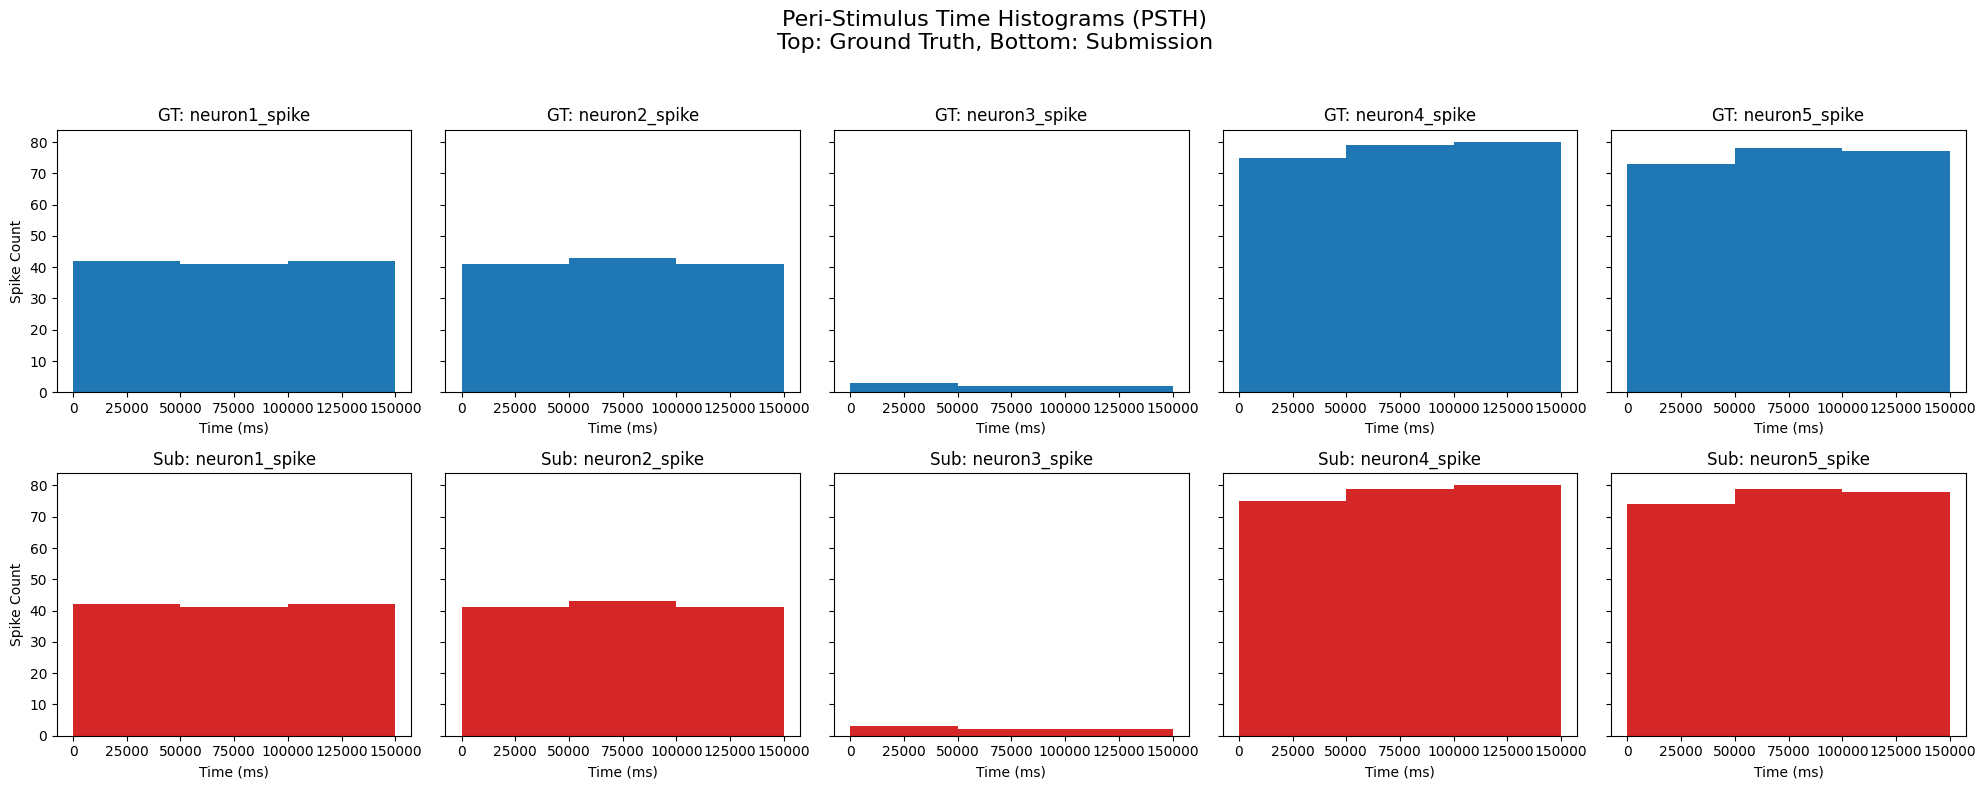

In [72]:
peri_bin_size = 50000
num_bins = gt_concat_df.shape[0] // peri_bin_size
spike_columns = [col for col in gt_concat_df.columns if col.endswith('_spike')]
num_neurons = len(spike_columns)
time_bins = np.arange(num_bins) * peri_bin_size

def compute_psth_concat(df, spike_columns, num_bins, peri_bin_size, num_neurons):
    binned_spikes = np.zeros((num_bins, num_neurons))
    for n, col in enumerate(spike_columns):
        spikes = df[col].values[:num_bins * peri_bin_size]
        binned_spikes[:, n] = spikes.reshape(num_bins, peri_bin_size).sum(axis=1)
    return binned_spikes

mean_gt_spike_counts = compute_psth_concat(gt_concat_df, spike_columns, num_bins, peri_bin_size, num_neurons)
mean_sub_spike_counts = compute_psth_concat(sub_concat_df, spike_columns, num_bins, peri_bin_size, num_neurons)

fig, axes = plt.subplots(2, num_neurons, figsize=(4*num_neurons, 8), sharey=True)
for i, col in enumerate(spike_columns):
    axes[0, i].bar(time_bins, mean_gt_spike_counts[:, i], width=peri_bin_size, align='edge', color='tab:blue')
    axes[0, i].set_title(f'GT: {col}')
    axes[0, i].set_xlabel('Time (ms)')
    if i == 0:
        axes[0, i].set_ylabel('Spike Count')
    axes[1, i].bar(time_bins, mean_sub_spike_counts[:, i], width=peri_bin_size, align='edge', color='tab:red')
    axes[1, i].set_title(f'Sub: {col}')
    axes[1, i].set_xlabel('Time (ms)')
    if i == 0:
        axes[1, i].set_ylabel('Spike Count')
plt.suptitle('Peri-Stimulus Time Histograms (PSTH)\nTop: Ground Truth, Bottom: Submission', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('charts/peri_stim_histogram.png', format='png')
plt.show()


In [73]:
ks_results = {}
for col in spike_columns:
    gt_spikes = gt_concat_df[col].values
    sub_spikes = sub_concat_df[col].values
    stat, pvalue = ks_2samp(gt_spikes, sub_spikes)
    ks_results[col] = {'statistic': stat, 'pvalue': pvalue}
    print(f"{col}: KS statistic={stat:.4f}, p-value={pvalue:.4e}")

neuron1_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron2_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron3_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron4_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron5_spike: KS statistic=0.0000, p-value=1.0000e+00


### PSTH Metrics

In [74]:
pearson_corrs = []
for i in range(num_neurons):
    corr, _ = pearsonr(psth_gt[:, i], psth_sub[:, i])
    pearson_corrs.append(corr)
    print(f"Neuron {i+1}: Pearson correlation = {corr:.4f}")



Neuron 1: Pearson correlation = 1.0000
Neuron 2: Pearson correlation = 1.0000
Neuron 3: Pearson correlation = 1.0000
Neuron 4: Pearson correlation = 1.0000
Neuron 5: Pearson correlation = 0.9934


In [75]:

mse_per_neuron = []
for i in range(num_neurons):
    mse = mean_squared_error(psth_gt[:, i], psth_sub[:, i])
    mse_per_neuron.append(mse)
    print(f"Neuron {i+1}: MSE = {mse:.6e}")



Neuron 1: MSE = 0.000000e+00
Neuron 2: MSE = 0.000000e+00
Neuron 3: MSE = 0.000000e+00
Neuron 4: MSE = 0.000000e+00
Neuron 5: MSE = 3.222222e-09


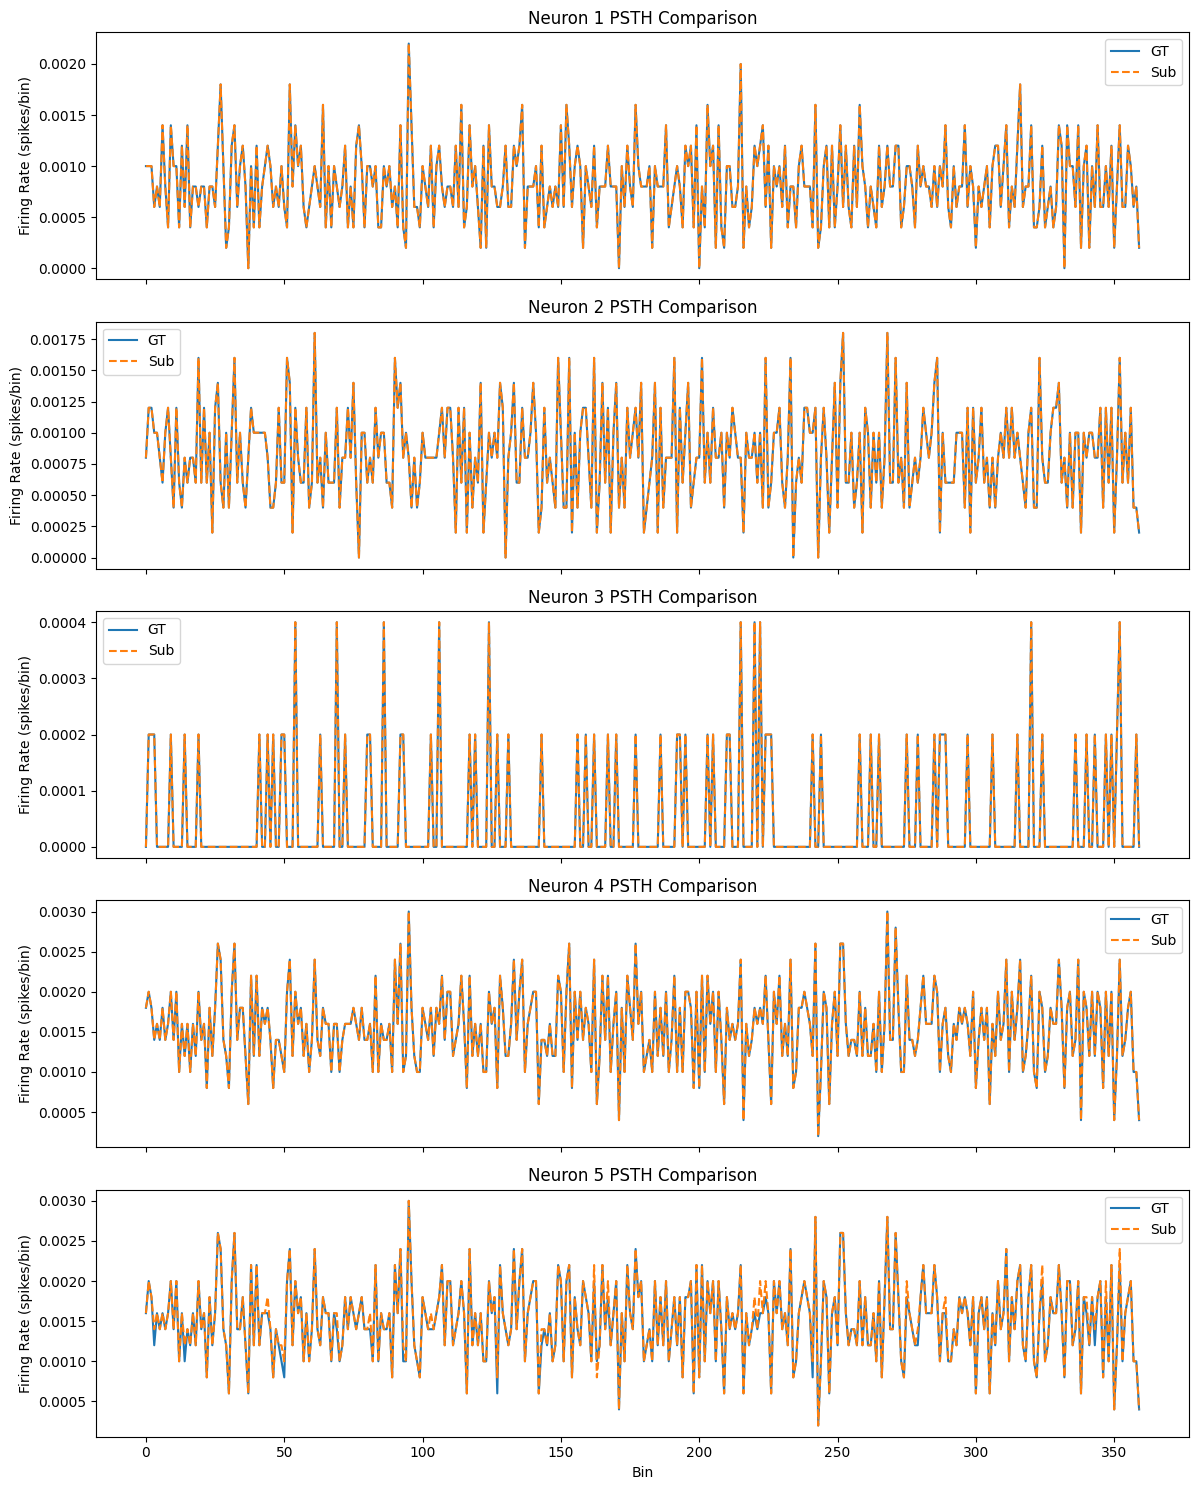

In [76]:
fig, axes = plt.subplots(num_neurons, 1, figsize=(12, 3 * num_neurons), sharex=True)
for i in range(num_neurons):
    axes[i].plot(psth_gt[:, i], label='GT', linestyle='-')
    axes[i].plot(psth_sub[:, i], label='Sub', linestyle='--')
    axes[i].set_ylabel('Firing Rate (spikes/bin)')
    axes[i].set_title(f'Neuron {i+1} PSTH Comparison')
    axes[i].legend()
axes[-1].set_xlabel('Bin')
plt.tight_layout()
plt.show()

### Rate Based Metrics

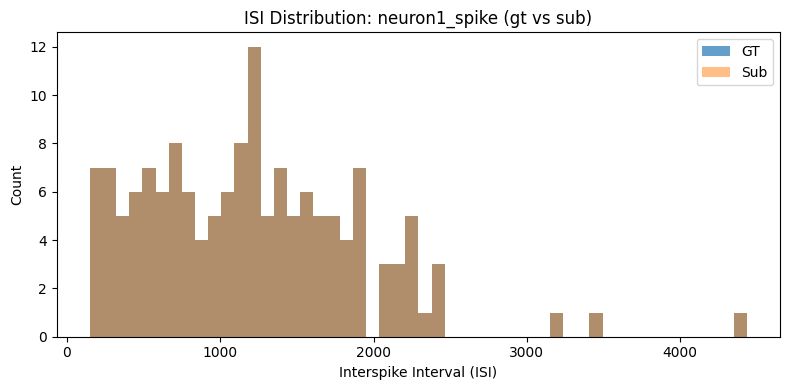

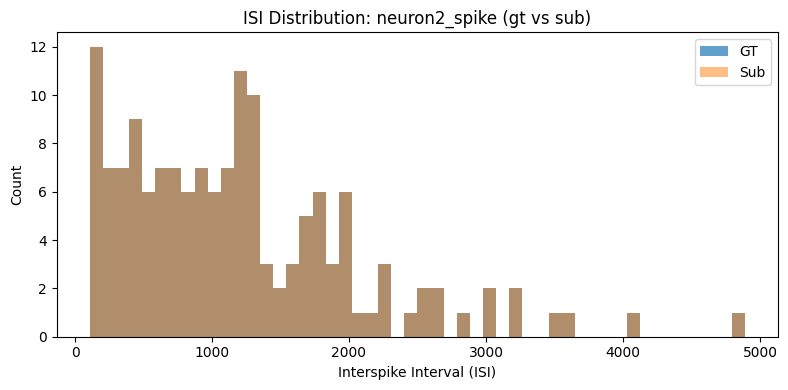

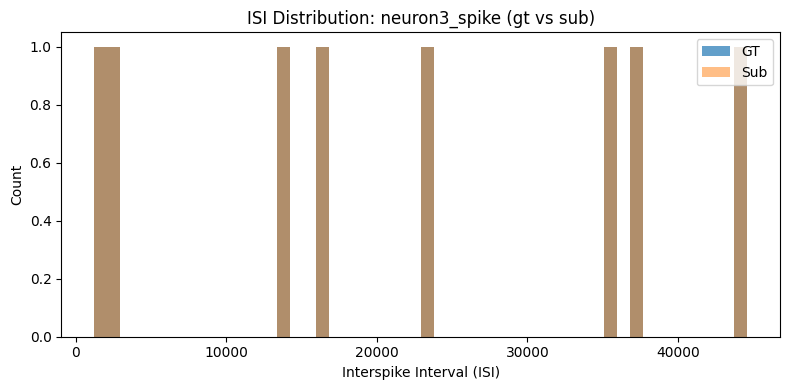

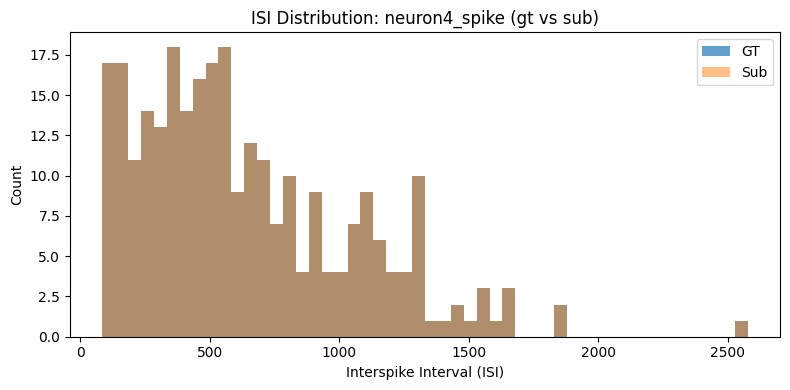

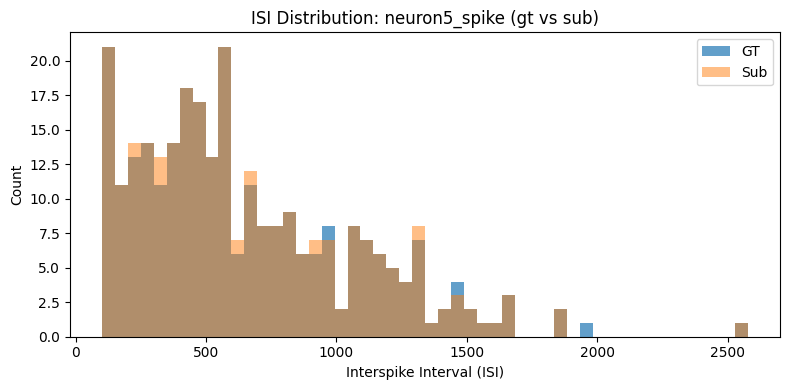

In [77]:
def plot_isi_per_neuron_compare(gt_df, sub_df, spike_columns):
    for col in spike_columns:
        gt_spike_times = np.where(gt_df[col].values == 1)[0]
        sub_spike_times = np.where(sub_df[col].values == 1)[0]
        gt_isis = np.diff(gt_spike_times)
        sub_isis = np.diff(sub_spike_times)
        plt.figure(figsize=(8, 4))
        plt.hist(gt_isis, bins=50, color='tab:blue', alpha=0.7, label='GT')
        plt.hist(sub_isis, bins=50, color='tab:orange', alpha=0.5, label='Sub')
        plt.xlabel('Interspike Interval (ISI)')
        plt.ylabel('Count')
        plt.title(f'ISI Distribution: {col} (gt vs sub)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'charts/isi_dist_{col.replace("_spike", "")}.png', format='png')
        plt.show()

plot_isi_per_neuron_compare(gt_concat_df, sub_concat_df, spike_columns)


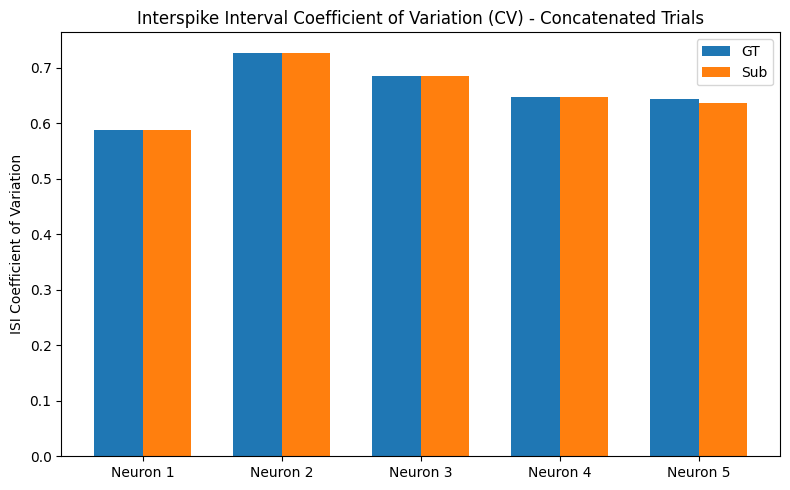

In [78]:
def compute_isi_cv(df, spike_columns):
    cvs = []
    for col in spike_columns:
        spike_times = np.where(df[col].values == 1)[0]
        isis = np.diff(spike_times)
        if len(isis) > 1:
            cv = np.std(isis) / np.mean(isis)
        else:
            cv = np.nan
        cvs.append(cv)
    return cvs

# Compute ISI CV for concatenated ground truth and submission dataframes
gt_cv_concat = compute_isi_cv(gt_concat_df, spike_columns)
sub_cv_concat = compute_isi_cv(sub_concat_df, spike_columns)

neuron_labels = [f'Neuron {i+1}' for i in range(num_neurons)]
x = np.arange(num_neurons)

plt.figure(figsize=(8, 5))
bar_width = 0.35
plt.bar(x - bar_width/2, gt_cv_concat, bar_width, label='GT', color='tab:blue')
plt.bar(x + bar_width/2, sub_cv_concat, bar_width, label='Sub', color='tab:orange')
plt.xticks(x, neuron_labels)
plt.ylabel('ISI Coefficient of Variation')
plt.title('Interspike Interval Coefficient of Variation (CV) - Concatenated Trials')
plt.legend()
plt.tight_layout()
plt.savefig('charts/isi_cv.png', format='png')
plt.show()


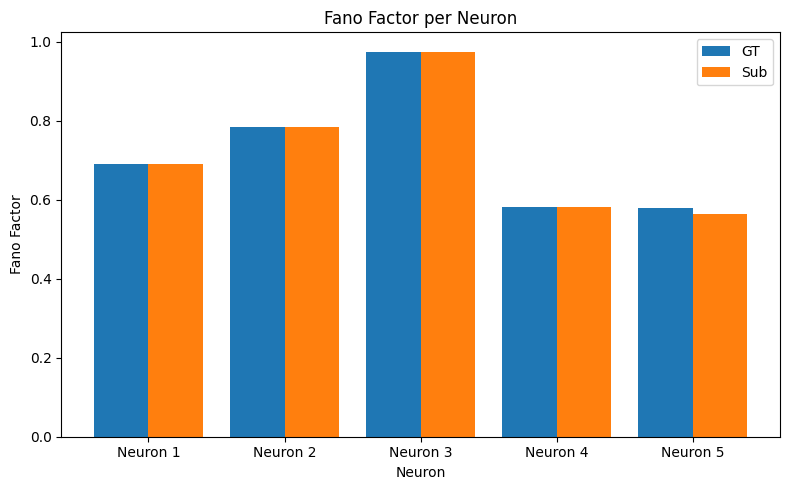

In [79]:
def spike_rate_and_fano(df, spike_columns, bin_size):
    num_bins = df.shape[0] // bin_size
    rates = []
    fanos = []
    for col in spike_columns:
        spikes = df[col].values[:num_bins * bin_size]
        binned_counts = spikes.reshape(num_bins, bin_size).sum(axis=1)
        rate = binned_counts.mean() / bin_size
        fano = np.var(binned_counts) / np.mean(binned_counts) if np.mean(binned_counts) > 0 else np.nan
        rates.append(rate)
        fanos.append(fano)
    return rates, fanos

gt_rates, gt_fanos = spike_rate_and_fano(gt_concat_df, spike_columns, bin_size)
sub_rates, sub_fanos = spike_rate_and_fano(sub_concat_df, spike_columns, bin_size)

plt.figure(figsize=(8, 5))
x = np.arange(len(spike_columns))
plt.bar(x - 0.2, gt_fanos, width=0.4, label='GT', color='tab:blue')
plt.bar(x + 0.2, sub_fanos, width=0.4, label='Sub', color='tab:orange')
plt.xticks(x, neuron_labels)
plt.ylabel('Fano Factor')
plt.xlabel('Neuron')
plt.title('Fano Factor per Neuron')
plt.legend()
plt.tight_layout()
plt.savefig('charts/fano_factor.png', format='png')
plt.show()

# Similarity Metrics

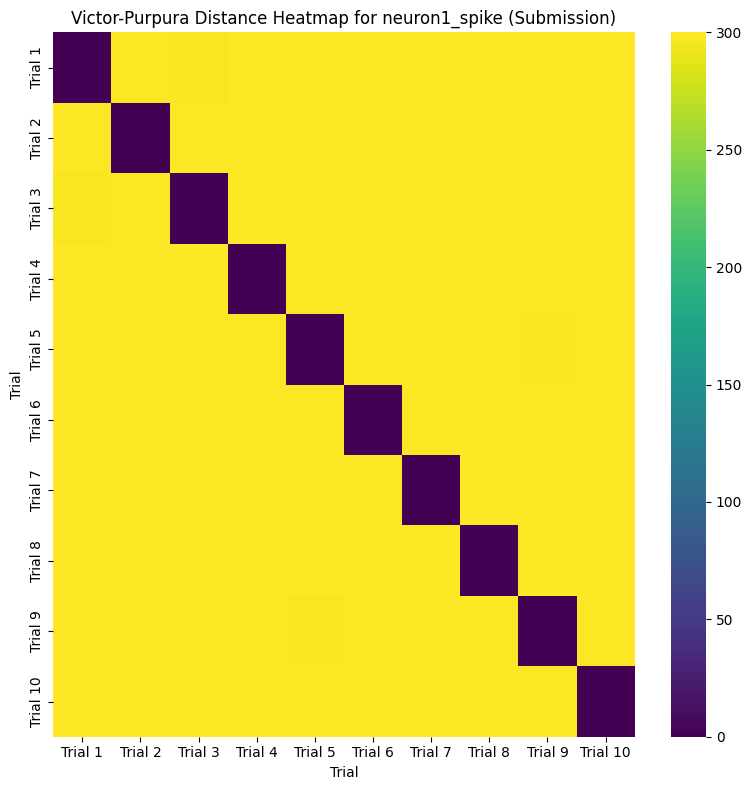

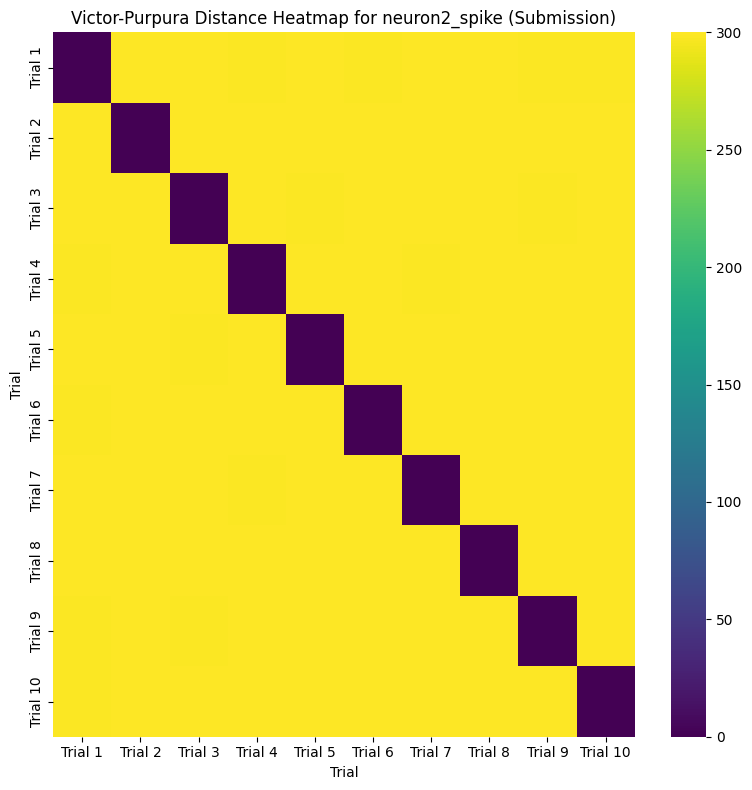

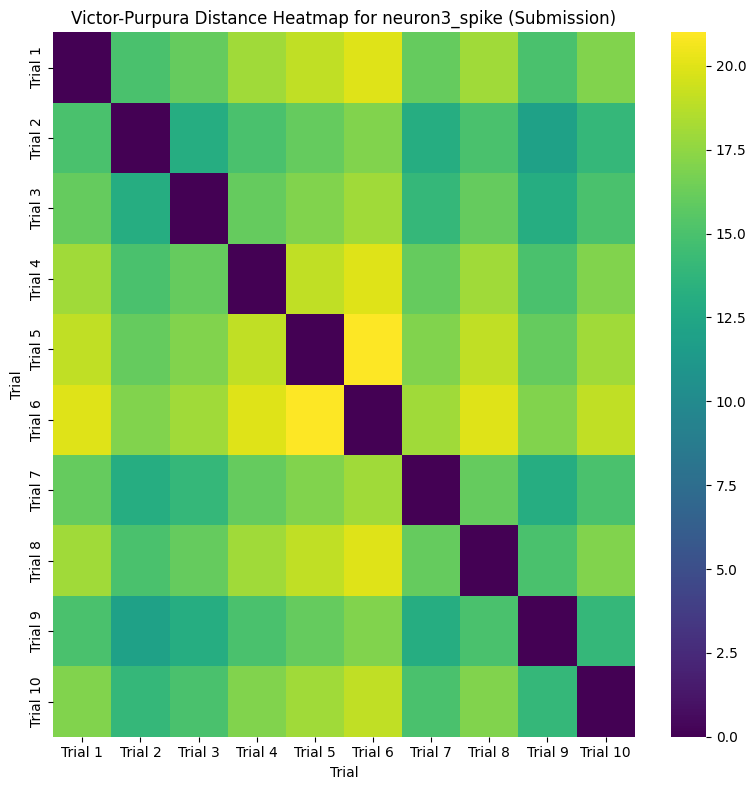

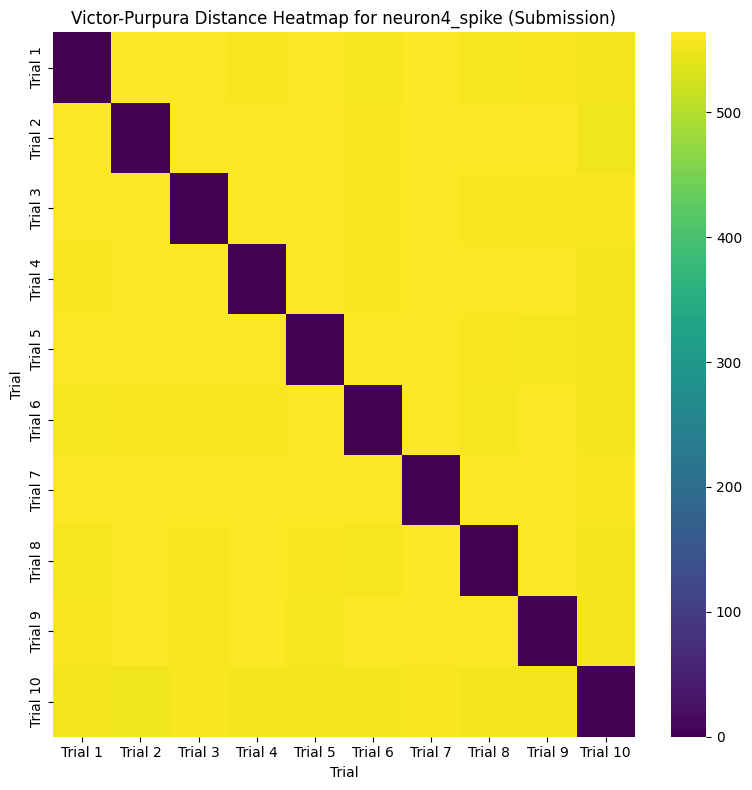

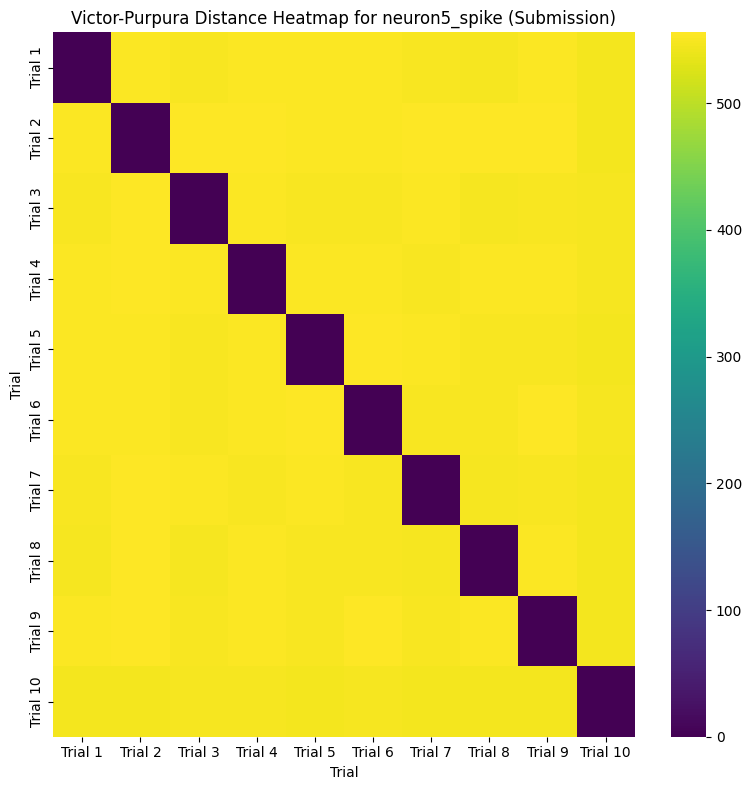

In [80]:
def victor_purpura_distance(trace1, trace2, q=1.0):
    spike_times1 = np.where(trace1 == 1)[0]
    spike_times2 = np.where(trace2 == 1)[0]
    n = len(spike_times1)
    m = len(spike_times2)
    dp = np.zeros((n+1, m+1))
    dp[:,0] = np.arange(n+1)
    dp[0,:] = np.arange(m+1)
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = q * abs(spike_times1[i-1] - spike_times2[j-1])
            dp[i,j] = min(
                dp[i-1,j] + 1,
                dp[i,j-1] + 1,
                dp[i-1,j-1] + cost
            )
    return dp[n,m]

vp_distances = {}
for neuron in spike_columns:
    vp_distances[neuron] = []
    for i in range(len(sub_trials)):
        for j in range(i+1, len(sub_trials)):
            d = victor_purpura_distance(
                sub_trials[i][neuron].values, 
                sub_trials[j][neuron].values, 
                q=1.0
            )
            vp_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})

for neuron in spike_columns:
    distances = vp_distances[neuron]
    trial_numbers = sorted(set([pair['trial_pair'][0] for pair in distances] + [pair['trial_pair'][1] for pair in distances]))
    n_trials = max(trial_numbers)
    vp_matrix = np.zeros((n_trials, n_trials))
    vp_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vp_matrix[i-1, j-1] = entry['distance']
        vp_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vp_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vp_matrix, annot=False, cmap='viridis', 
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)], 
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Victor-Purpura Distance Heatmap for {neuron} (Submission)')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()


Van Rossum Metric

In [81]:
def van_rossum_distance(trace1, trace2, tau=20.0):
    t = np.arange(len(trace1))
    kernel = np.exp(-t / tau)
    conv1 = np.convolve(trace1, kernel, mode='full')[:len(trace1)]
    conv2 = np.convolve(trace2, kernel, mode='full')[:len(trace2)]
    return np.sqrt(np.sum((conv1 - conv2) ** 2) / len(trace1))

van_rossum_distances = {}
tau = 20.0  # ms, can be adjusted
NUM_TRIALS = len(sub_trials)

for neuron in spike_columns:
    van_rossum_distances[neuron] = []
    for i in range(NUM_TRIALS):
        for j in range(i+1, NUM_TRIALS):
            d = van_rossum_distance(
                sub_trials[i][neuron].values,
                sub_trials[j][neuron].values,
                tau=tau
            )
            van_rossum_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})

for neuron in spike_columns:
    distances = van_rossum_distances[neuron]
    n_trials = NUM_TRIALS
    vr_matrix = np.zeros((n_trials, n_trials))
    vr_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vr_matrix[i-1, j-1] = entry['distance']
        vr_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vr_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vr_matrix, annot=False, cmap='viridis',
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)],
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Van Rossum Distance Heatmap for {neuron} (Submission)')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

Granger Causality

Cross Correlation

Cross-correlogram for Ground Truth (Concatenated)


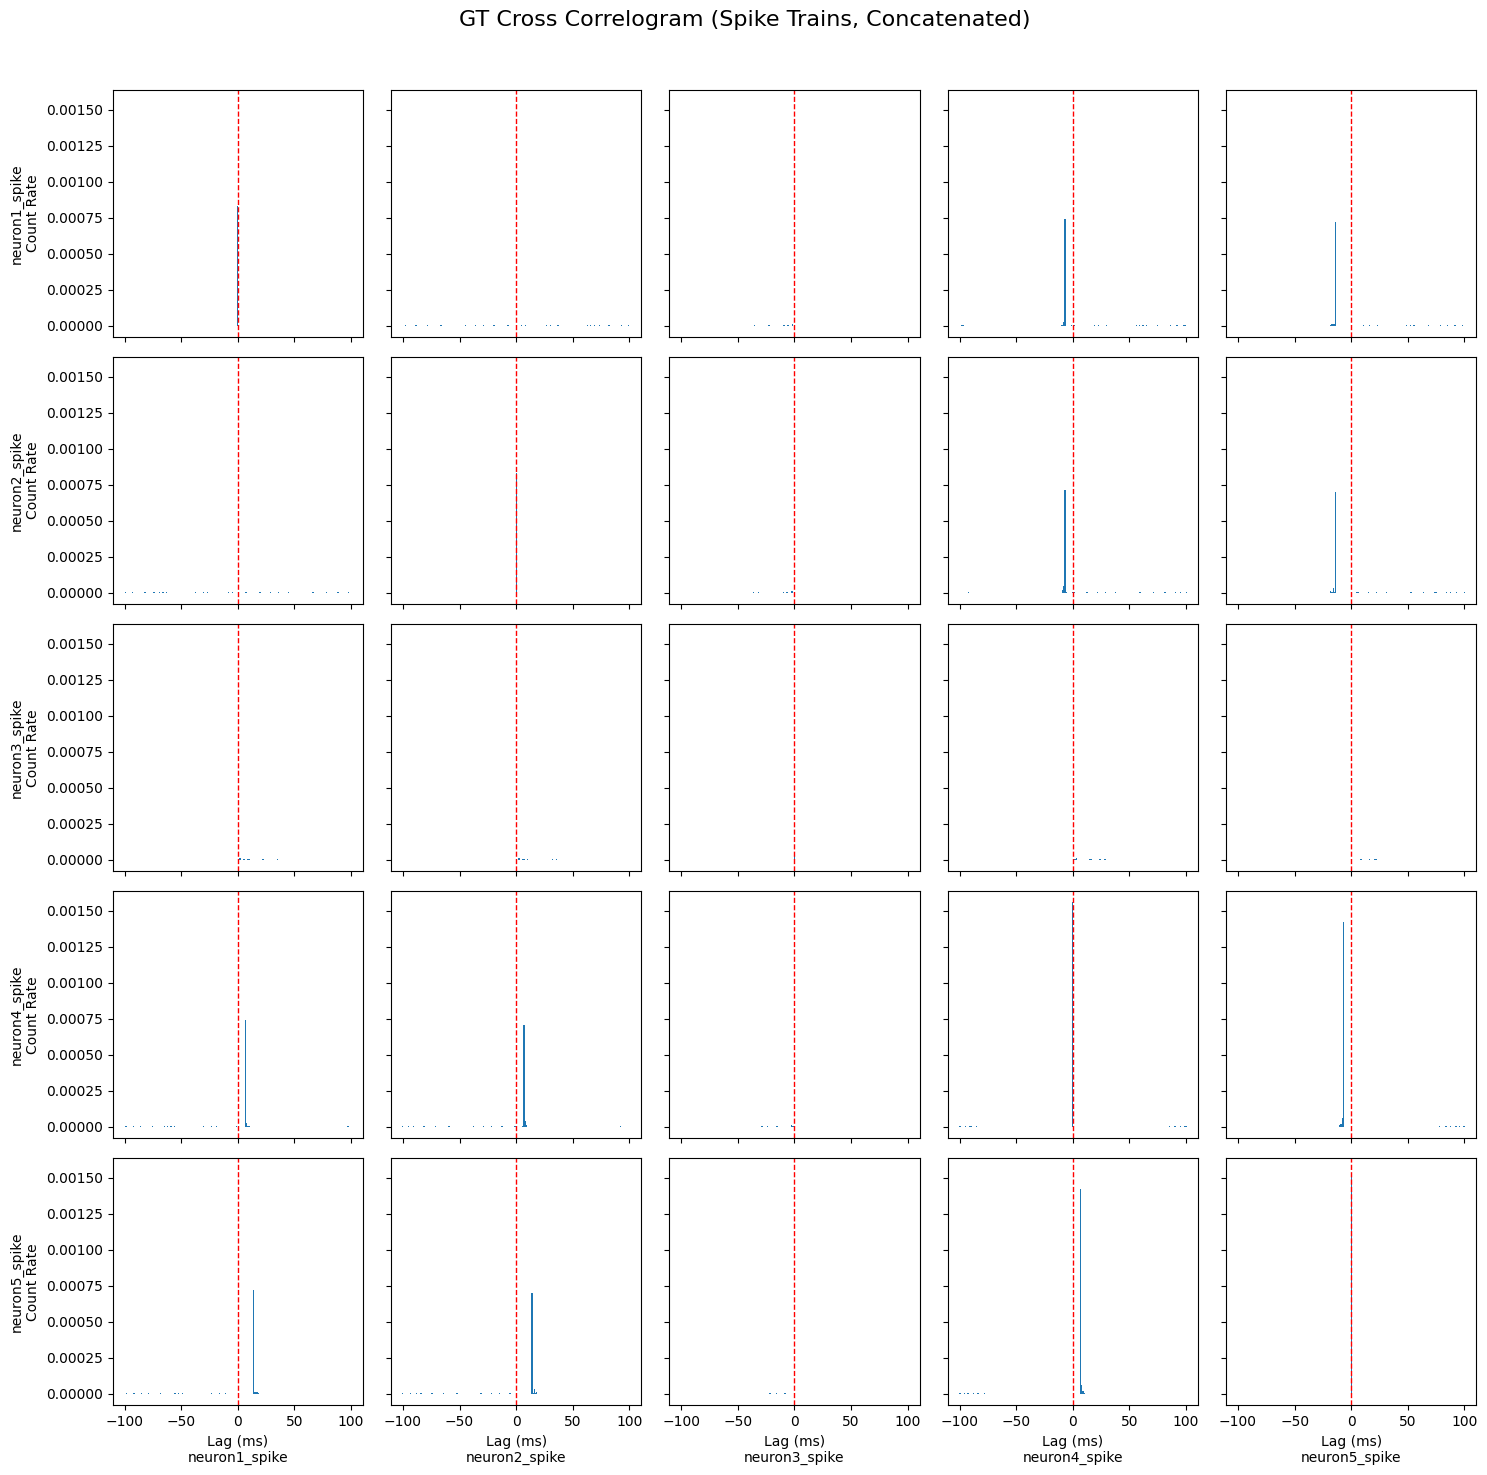

Cross-correlogram for Submission (Concatenated)


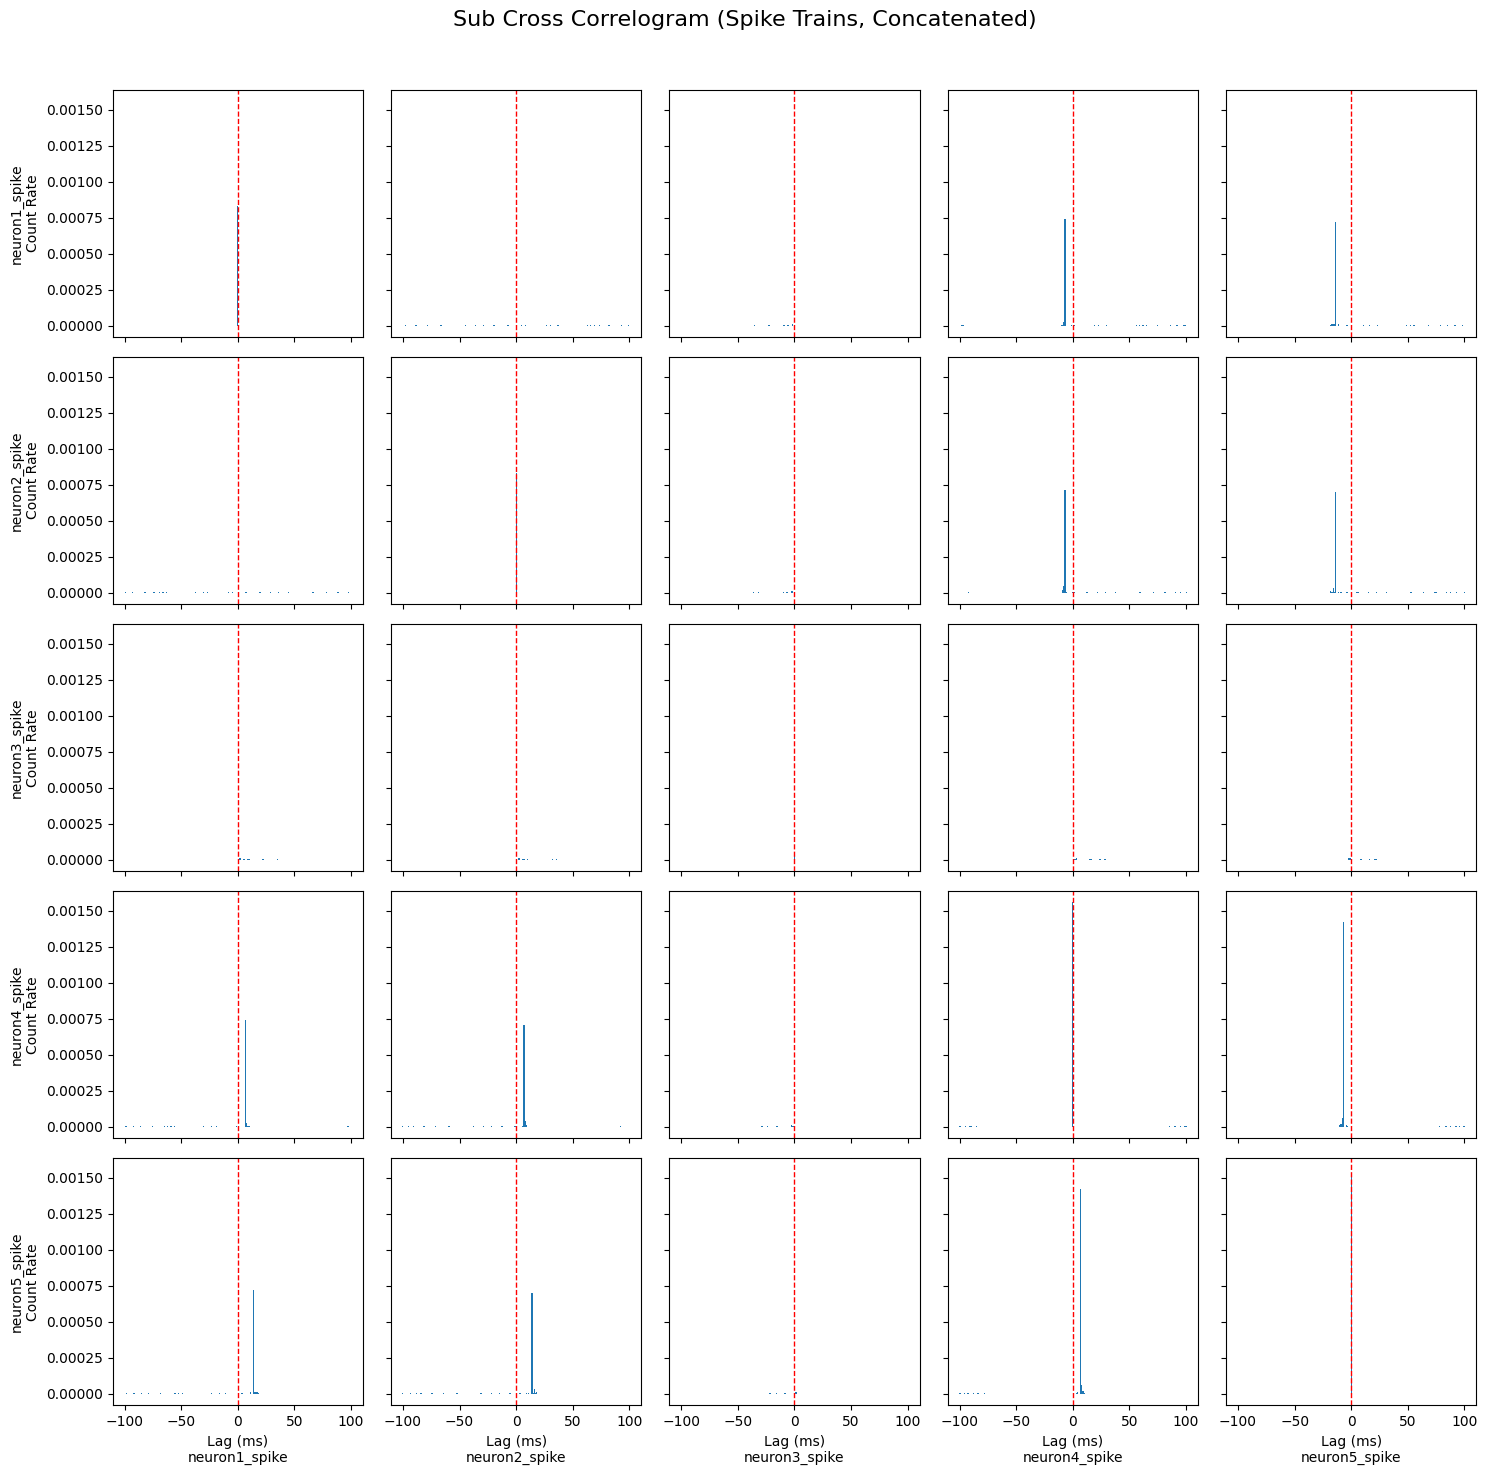

In [82]:
def plot_cross_correlogram(df, spike_columns, max_lag=100, bin_size=1, title_prefix=''):
    num_neurons = len(spike_columns)
    fig, axes = plt.subplots(num_neurons, num_neurons, figsize=(3*num_neurons, 3*num_neurons), sharex=True, sharey=True)
    lags = np.arange(-max_lag, max_lag+1, bin_size)
    for i, col_i in enumerate(spike_columns):
        spikes_i = df[col_i].values
        for j, col_j in enumerate(spike_columns):
            spikes_j = df[col_j].values
            corr = np.correlate(spikes_i - np.mean(spikes_i), spikes_j - np.mean(spikes_j), mode='full')
            center = len(corr) // 2
            corr_lags = corr[center-max_lag:center+max_lag+1]
            corr_rate = corr_lags / df.shape[0]
            ax = axes[i, j] if num_neurons > 1 else axes
            ax.bar(lags, corr_rate, width=1, color='tab:blue')
            if i == num_neurons - 1:
                ax.set_xlabel(f"Lag (ms)\n{col_j}")
            if j == 0:
                ax.set_ylabel(f"{col_i}\nCount Rate")
            ax.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.suptitle(f"{title_prefix} Cross Correlogram (Spike Trains, Concatenated)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("Cross-correlogram for Ground Truth (Concatenated)")
plot_cross_correlogram(gt_concat_df, spike_columns, max_lag=100, bin_size=1, title_prefix='GT')

print("Cross-correlogram for Submission (Concatenated)")
plot_cross_correlogram(sub_concat_df, spike_columns, max_lag=100, bin_size=1, title_prefix='Sub')

# Membrane Potential Metrics
Getting Resting Potentials

In [83]:
mempot_cols = [col for col in gt_concat_df.columns if col.endswith('_mempot')]

gt_rest_pot = {}
for col in mempot_cols:
    rest_val = gt_concat_df[col].median()
    gt_rest_pot[col] = rest_val

print("Resting potentials from concatenated ground truth data:")
for col, val in gt_rest_pot.items():
    print(f"  {col}: {val:.4f}")


Resting potentials from concatenated ground truth data:
  neuron1_mempot: -60.0000
  neuron2_mempot: -60.0000
  neuron3_mempot: -60.0000
  neuron4_mempot: -60.0001
  neuron5_mempot: -60.0001


In [84]:
sub_rest_pot = {}
for col in mempot_cols:
    rest_val = sub_concat_df[col].median()
    sub_rest_pot[col] = rest_val

print("Resting potentials from concatenated submission data:")
for col, val in sub_rest_pot.items():
    print(f"  {col}: {val:.4f}")


Resting potentials from concatenated submission data:
  neuron1_mempot: -60.0000
  neuron2_mempot: -60.0000
  neuron3_mempot: -60.0000
  neuron4_mempot: -60.0001
  neuron5_mempot: -60.0001


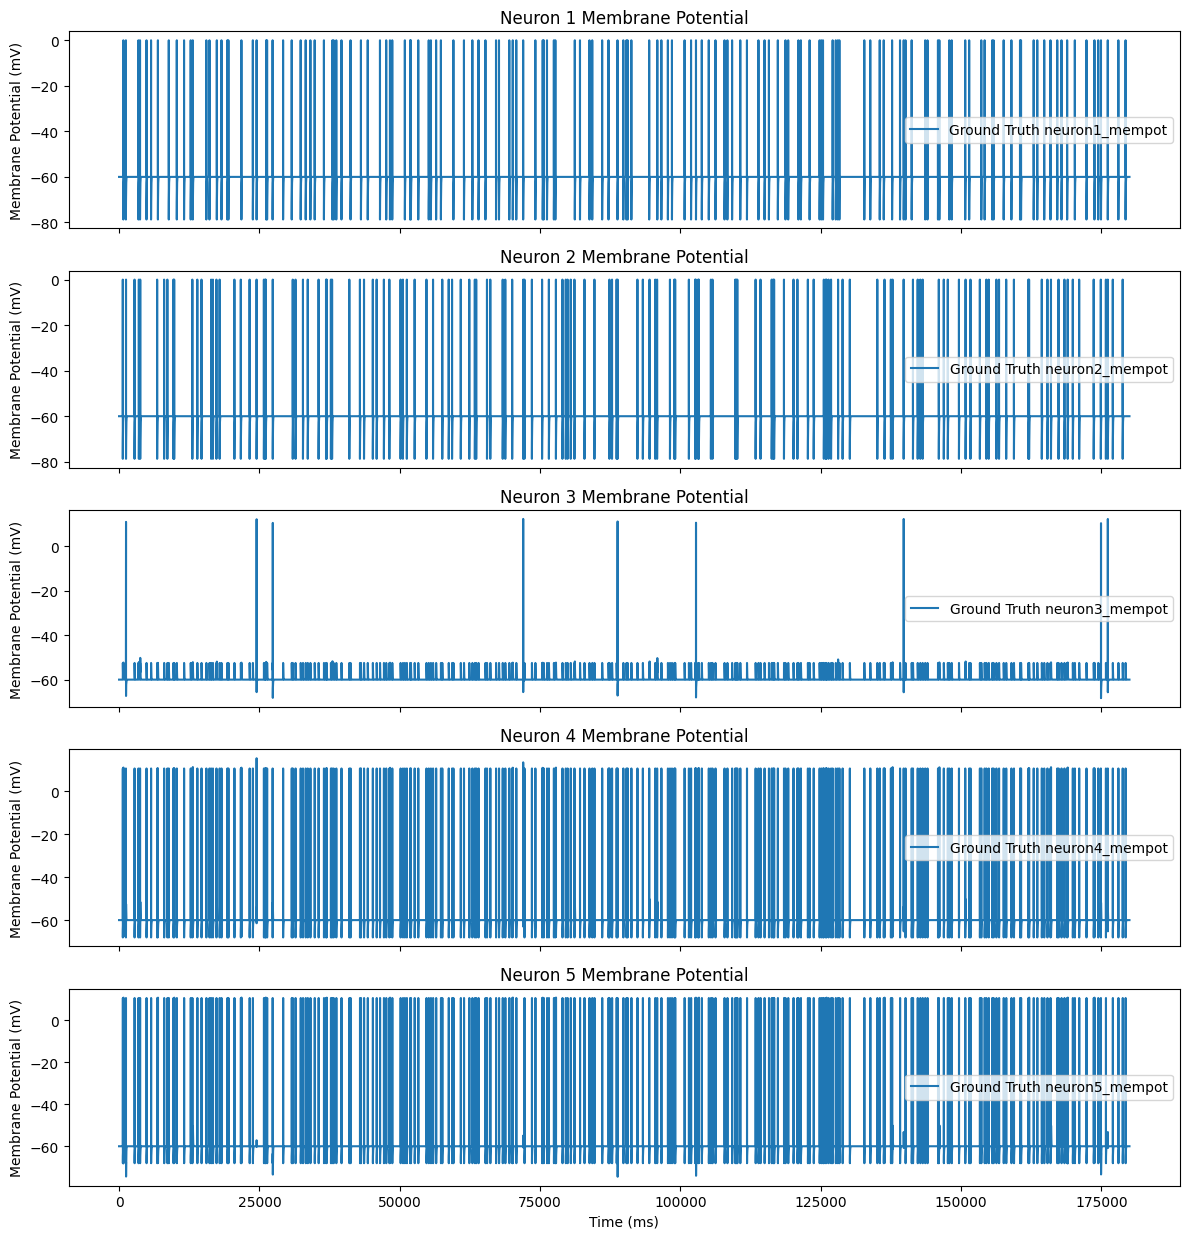

In [85]:
fig, axes = plt.subplots(num_neurons, 1, figsize=(12, 2.5 * num_neurons), sharex=True)
for i, col in enumerate(mempot_cols):
    axes[i].plot(gt_concat_df['time'], gt_concat_df[col], label=f'Ground Truth {col}', color='tab:blue')
    axes[i].set_ylabel('Membrane Potential (mV)')
    axes[i].set_title(f'{neuron_labels[i]} Membrane Potential')
    axes[i].legend()
axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

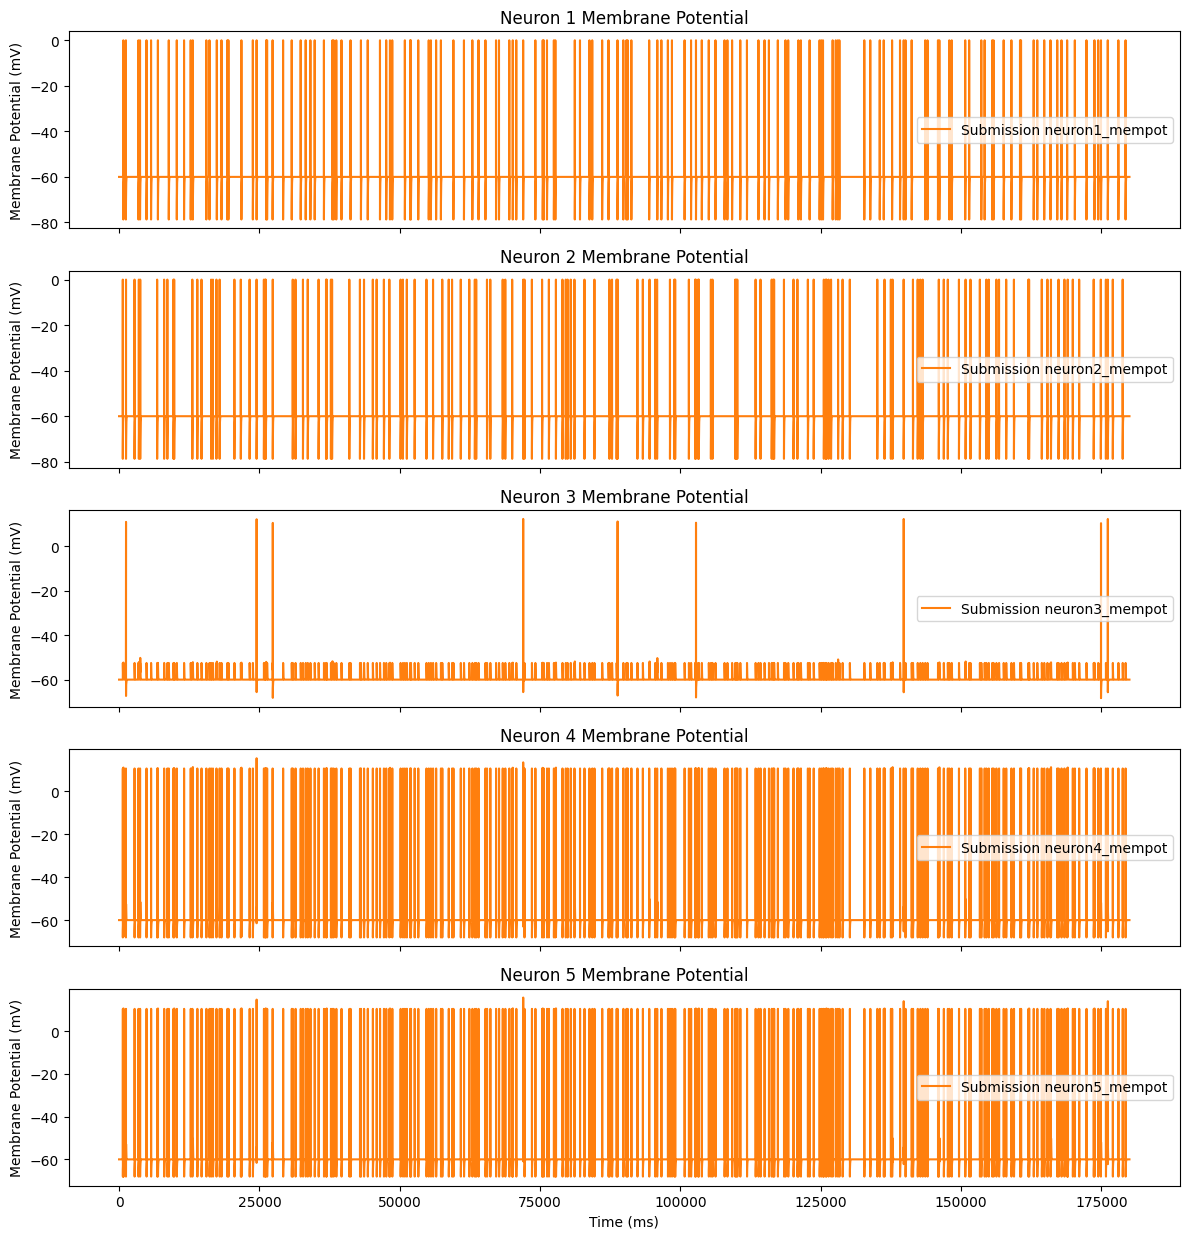

In [86]:
fig, axes = plt.subplots(num_neurons, 1, figsize=(12, 2.5 * num_neurons), sharex=True)
for i, col in enumerate(mempot_cols):
    axes[i].plot(sub_concat_df['time'], sub_concat_df[col], label=f'Submission {col}', color='tab:orange')
    axes[i].set_ylabel('Membrane Potential (mV)')
    axes[i].set_title(f'{neuron_labels[i]} Membrane Potential')
    axes[i].legend()
axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

Filtering out the action potentials

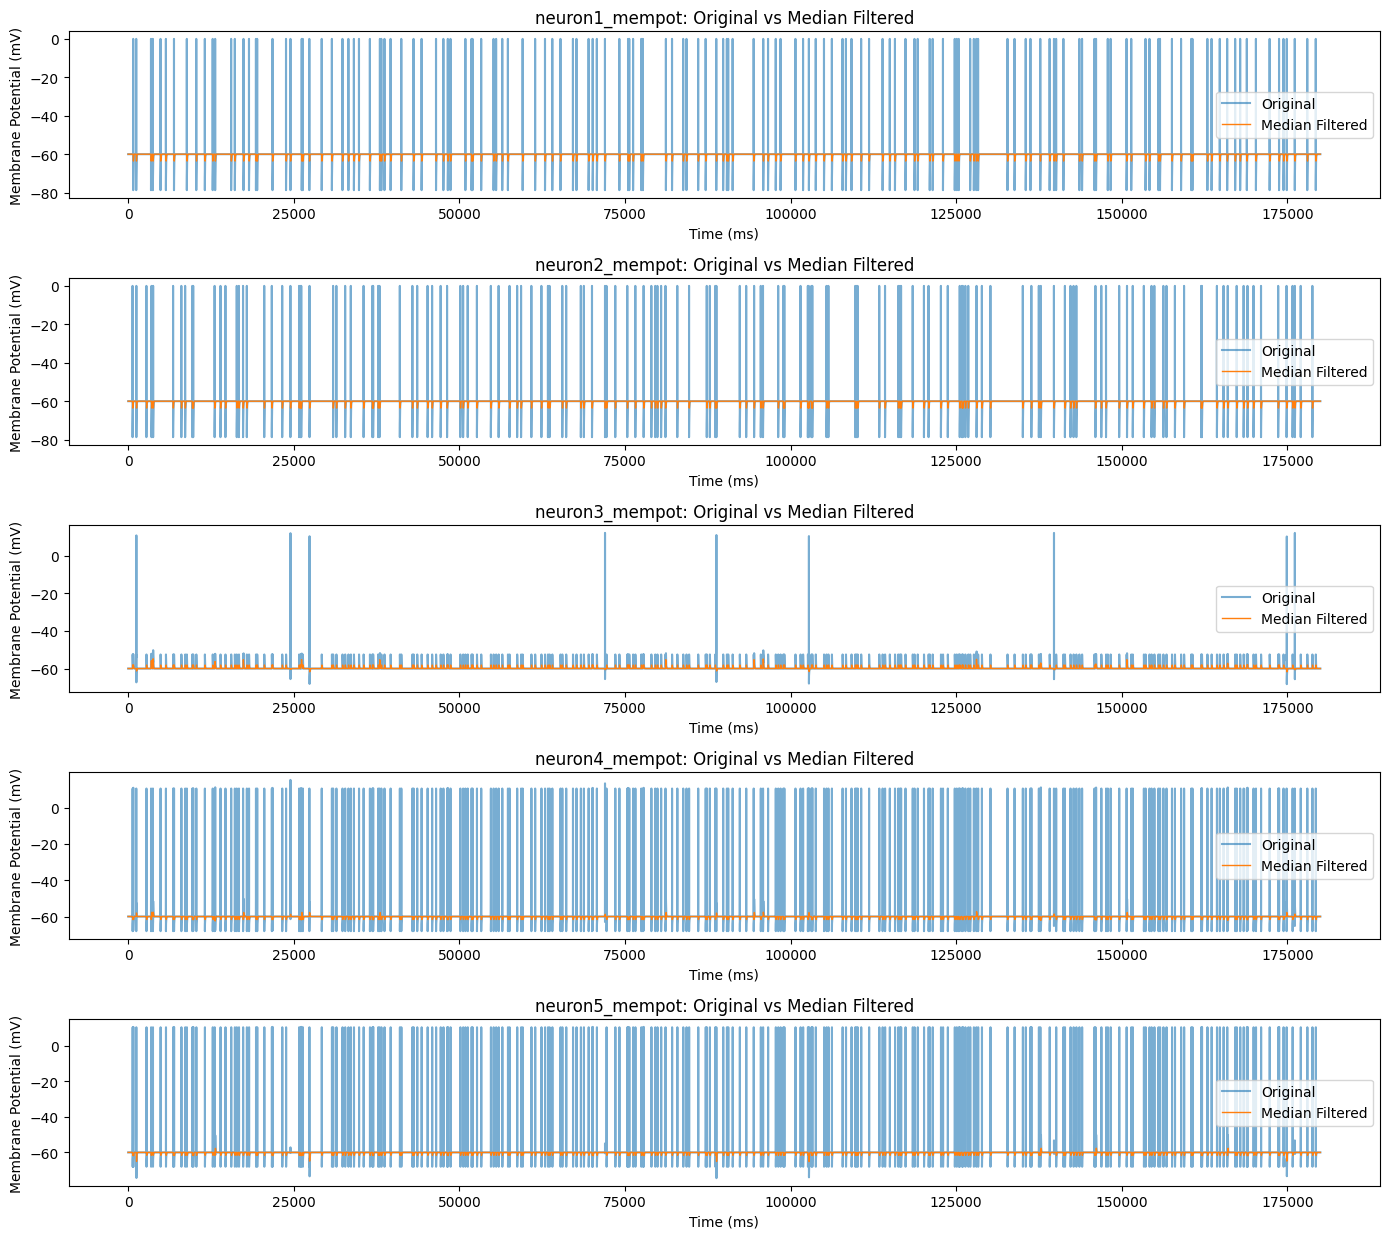

In [87]:

gt_filtered_mempot = {}
kernel_size = 101  # Choose an odd number, adjust as need

for col in mempot_cols:
    gt_filtered_mempot[col] = medfilt(gt_concat_df[col].values, kernel_size=kernel_size)

plt.figure(figsize=(14, 2.5 * len(mempot_cols)))
for i, col in enumerate(mempot_cols):
    plt.subplot(len(mempot_cols), 1, i + 1)
    plt.plot(gt_concat_df['time'], gt_concat_df[col], label='Original', alpha=0.6)
    plt.plot(gt_concat_df['time'], gt_filtered_mempot[col], label='Median Filtered', linewidth=1)
    plt.xlabel('Time (ms)')
    plt.ylabel('Membrane Potential (mV)')
    plt.title(f'{col}: Original vs Median Filtered')
    plt.legend()
plt.tight_layout()
plt.savefig('charts/gt_filtered_mempot.png', format='png')
plt.show()

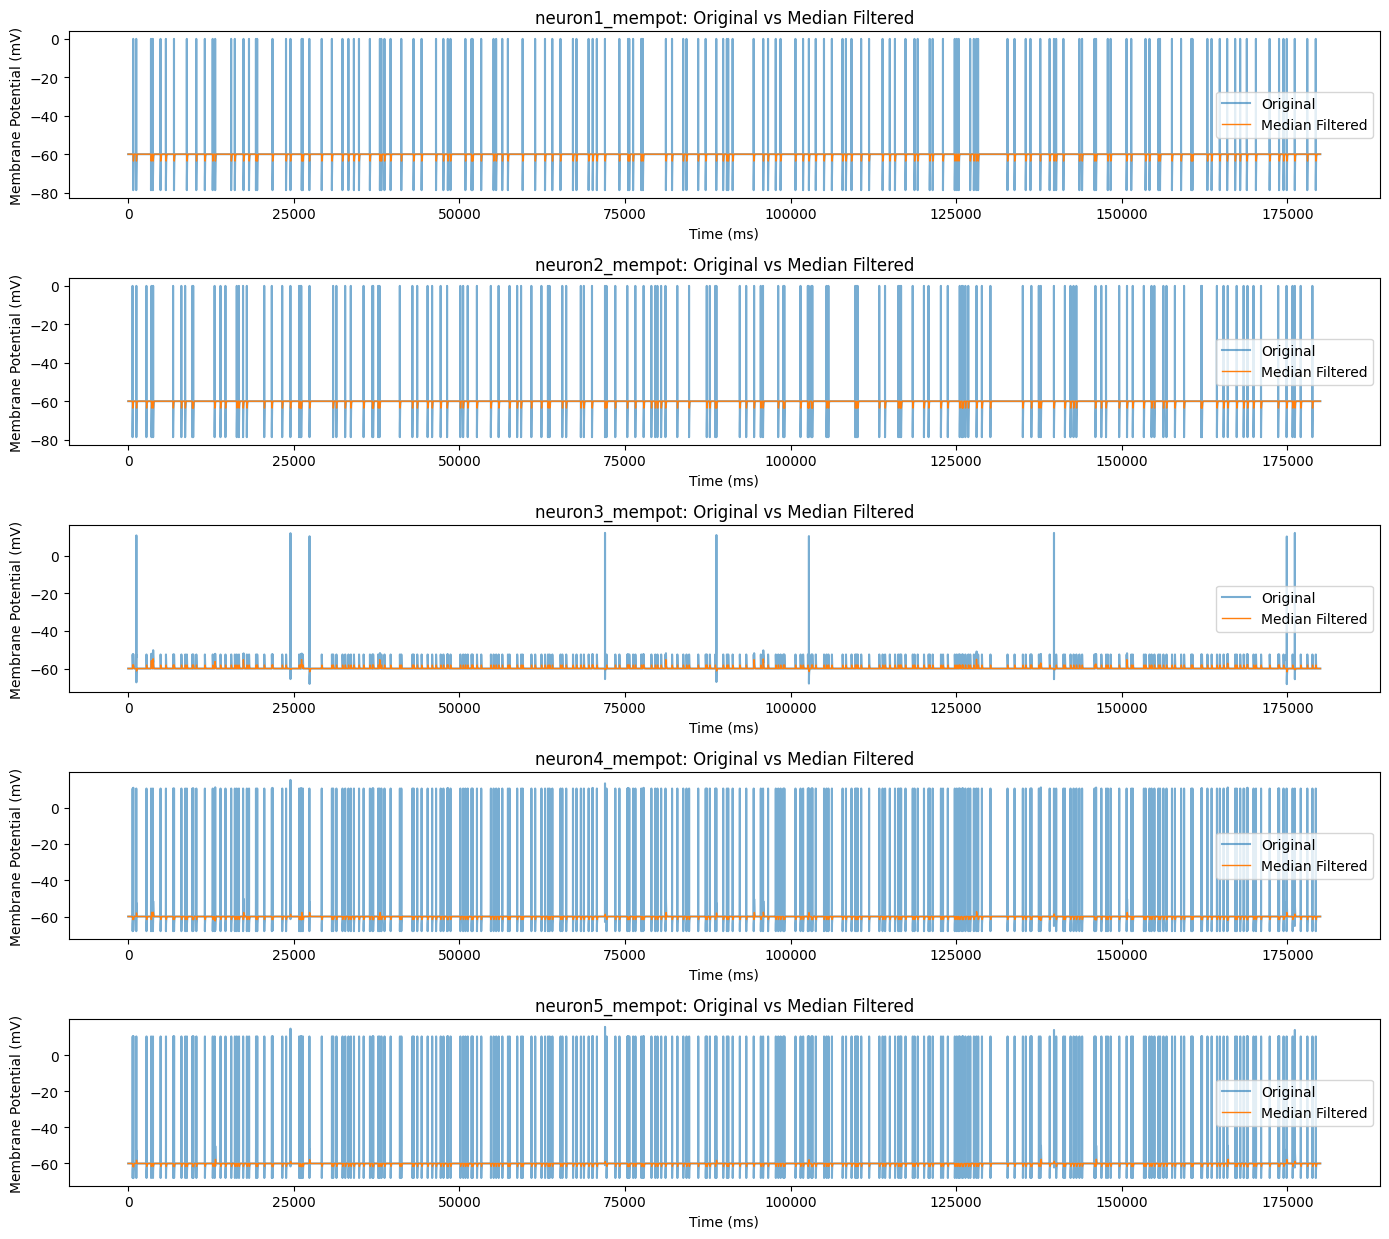

In [88]:
from scipy.signal import medfilt

sub_filtered_mempot = {}
kernel_size = 101  # Choose an odd number, adjust as need

for col in mempot_cols:
    sub_filtered_mempot[col] = medfilt(sub_concat_df[col].values, kernel_size=kernel_size)

plt.figure(figsize=(14, 2.5 * len(mempot_cols)))
for i, col in enumerate(mempot_cols):
    plt.subplot(len(mempot_cols), 1, i + 1)
    plt.plot(sub_concat_df['time'], sub_concat_df[col], label='Original', alpha=0.6)
    plt.plot(sub_concat_df['time'], sub_filtered_mempot[col], label='Median Filtered', linewidth=1)
    plt.xlabel('Time (ms)')
    plt.ylabel('Membrane Potential (mV)')
    plt.title(f'{col}: Original vs Median Filtered')
    plt.legend()
plt.tight_layout()
plt.savefig('charts/sub_filtered_mempot.png', format='png')
plt.show()

In [89]:
# Identify PSP (postsynaptic potential) events in gt_concat_df using filtered membrane potentials

gt_psp_events = {}

threshold = 1.0  # mV deviation from resting potential to consider as a PSP event (adjust as needed)

for col in mempot_cols:
    mempot = gt_filtered_mempot[col]
    rest = gt_rest_pot[col]
    # Find where membrane potential deviates from rest by more than threshold
    psp_mask = np.abs(mempot - rest) > threshold
    psp_indices = np.where(psp_mask)[0]
    gt_psp_events[col] = psp_indices

    print(f"{col}: {len(psp_indices)} PSP events detected")


neuron1_mempot: 13200 PSP events detected
neuron2_mempot: 13452 PSP events detected
neuron3_mempot: 19126 PSP events detected
neuron4_mempot: 20200 PSP events detected
neuron5_mempot: 19684 PSP events detected


In [90]:
# Identify PSP (postsynaptic potential) events in sub_concat_df using filtered membrane potentials

sub_psp_events = {}

threshold = 1.0  # mV deviation from resting potential to consider as a PSP event (adjust as needed)

for col in mempot_cols:
    mempot = sub_filtered_mempot[col]
    rest = sub_rest_pot[col]
    # Find where membrane potential deviates from rest by more than threshold
    psp_mask = np.abs(mempot - rest) > threshold
    psp_indices = np.where(psp_mask)[0]
    sub_psp_events[col] = psp_indices

    print(f"{col}: {len(psp_indices)} PSP events detected")


neuron1_mempot: 13200 PSP events detected
neuron2_mempot: 13452 PSP events detected
neuron3_mempot: 19126 PSP events detected
neuron4_mempot: 20200 PSP events detected
neuron5_mempot: 19704 PSP events detected


EPSP is a deviation in depolarization from the resting potential - makes more positive
IPSP is a deviation in hyperpolarization from the resting potential - makes more negative

In [91]:
# Classify each PSP event in gt_psp_events as EPSP or IPSP based on deviation from resting potential

gt_psp_classification = {}

for col in mempot_cols:
    rest = gt_rest_pot[col]
    mempot = gt_filtered_mempot[col]
    event_indices = gt_psp_events[col]
    epsp_indices = event_indices[mempot[event_indices] > rest]
    ipsp_indices = event_indices[mempot[event_indices] < rest]
    gt_psp_classification[col] = {
        'EPSP': epsp_indices,
        'IPSP': ipsp_indices
    }
    print(f"{col}: {len(epsp_indices)} EPSPs, {len(ipsp_indices)} IPSPs")

neuron1_mempot: 0 EPSPs, 13200 IPSPs
neuron2_mempot: 0 EPSPs, 13452 IPSPs
neuron3_mempot: 18792 EPSPs, 334 IPSPs
neuron4_mempot: 1245 EPSPs, 18955 IPSPs
neuron5_mempot: 287 EPSPs, 19397 IPSPs


In [92]:
# Classify each PSP event in sub_psp_events as EPSP or IPSP based on deviation from resting potential

sub_psp_classification = {}

for col in mempot_cols:
    rest = sub_rest_pot[col]
    mempot = sub_filtered_mempot[col]
    event_indices = sub_psp_events[col]
    epsp_indices = event_indices[mempot[event_indices] > rest]
    ipsp_indices = event_indices[mempot[event_indices] < rest]
    sub_psp_classification[col] = {
        'EPSP': epsp_indices,
        'IPSP': ipsp_indices
    }
    print(f"{col}: {len(epsp_indices)} EPSPs, {len(ipsp_indices)} IPSPs")

neuron1_mempot: 0 EPSPs, 13200 IPSPs
neuron2_mempot: 0 EPSPs, 13452 IPSPs
neuron3_mempot: 18792 EPSPs, 334 IPSPs
neuron4_mempot: 1245 EPSPs, 18955 IPSPs
neuron5_mempot: 814 EPSPs, 18890 IPSPs


# Output

In [93]:
rmse_per_neuron = [np.sqrt(v) for v in mse_per_neuron]
ks_stats = [ks_results[col]['statistic'] for col in spike_columns]
rmse_per_neuron_fmt = [float(f"{v:.4g}") for v in rmse_per_neuron]
ks_stats_fmt = [float(f"{v:.4g}") for v in ks_stats]
pearson_corrs_fmt = [float(f"{v:.4g}") for v in pearson_corrs]

summary_df = pd.DataFrame({
    'Neuron': neuron_labels,
    'KS Statistic': ks_stats_fmt,
    'Pearson Correlation': pearson_corrs_fmt,
    'RMSE': rmse_per_neuron_fmt
})

# Normalize the data to come up with a score
min_ks = summary_df['KS Statistic'].min()
max_ks = summary_df['KS Statistic'].max()
summary_df['KS_Normalized'] = 1 - (summary_df['KS Statistic'] - min_ks) / (max_ks - min_ks)

min_pearson = summary_df['Pearson Correlation'].min()
max_pearson = summary_df['Pearson Correlation'].max()
summary_df['Pearson_Normalized'] = (summary_df['Pearson Correlation'] - min_pearson) / (max_pearson - min_pearson)

min_rmse = summary_df['RMSE'].min()
max_rmse = summary_df['RMSE'].max()
summary_df['RMSE_Normalized'] = 1 - (summary_df['RMSE'] - min_rmse) / (max_rmse - min_rmse)

# weights
weight_ks = 0.2
weight_pearson = 0.6
weight_rmse = 0.2

summary_df['Overall Score'] = (
    summary_df['KS_Normalized'] * weight_ks +
    summary_df['Pearson_Normalized'] * weight_pearson +
    summary_df['RMSE_Normalized'] * weight_rmse
) * 100 # Scale to 0-100

summary_df = summary_df.drop(columns=['KS_Normalized', 'Pearson_Normalized', 'RMSE_Normalized'])
summary_df['Overall Score'] = summary_df['Overall Score'].round(2)

# Save summary table as an image using matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 1 + 0.5 * len(summary_df)))
ax.axis('off')
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(summary_df.columns))))
plt.tight_layout()
plt.savefig('charts/summary_table.png', bbox_inches='tight', dpi=200)
plt.close()

summary_df.to_csv('data/summary_df.csv', index=False)

print(summary_df)

# note to self.  Min max is often thrownoff by outliers.  Is there a better way to normalize.

     Neuron  KS Statistic  Pearson Correlation      RMSE  Overall Score
0  Neuron 1      0.000000               1.0000  0.000000          100.0
1  Neuron 2      0.000000               1.0000  0.000000          100.0
2  Neuron 3      0.000000               1.0000  0.000000          100.0
3  Neuron 4      0.000000               1.0000  0.000000          100.0
4  Neuron 5      0.000022               0.9934  0.000057            0.0


In [101]:

from reportlab.lib import colors

def first_page(canvas, document):
    title = 'Your Submission Report'
    PAGE_HEIGHT = defaultPageSize[1]
    PAGE_WIDTH = defaultPageSize[0]
    logo_path = 'templates/carbon_copies_cover.jpeg'  

    canvas.saveState()
    canvas.setFont('Times-Bold', 18)
    canvas.drawCentredString(PAGE_WIDTH/2.0, PAGE_HEIGHT-208, title)

    canvas.drawImage(logo_path, PAGE_WIDTH/2.0 - 1.5*inch, PAGE_HEIGHT-2.5*inch, width=3*inch, height=1.5*inch, preserveAspectRatio=True)

    canvas.setFont('Times-Roman', 10)
    text = 'Welcome to your submission report. This document contains the details of your submission.'

    canvas.drawString(inch, 8.5*inch, text)
    canvas.setFont('Times-Bold', 12)
    canvas.drawString(inch, 8.25*inch, 'Report metadata:')
    canvas.setFont('Times-Roman', 10)
    canvas.drawString(inch, 8.0*inch, 'Generated on: {}'.format(pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')))
    canvas.drawString(inch, 7.75*inch, 'Ground truth file: {}'.format(ground_truth))
    canvas.drawString(inch, 7.5*inch, 'Submission file: {}'.format(submission))

    canvas.drawString(inch, 7.25*inch, 'Total trials in ground truth: {}'.format(NUM_GT_TRIALS))
    canvas.drawString(inch, 7.0*inch, 'Total trials in submission: {}'.format(NUM_SUB_TRIALS))
    canvas.drawString(inch, 6.75*inch, 'Number of neurons in ground truth: {}'.format(num_gt_neurons))
    canvas.drawString(inch, 6.5*inch, 'Number of neurons in submission: {}'.format(num_sub_neurons))
    canvas.drawString(inch, 6.25*inch, 'Total number of trials in Ground Truth: {}'.format(len(gt_trials)))
    canvas.drawString(inch, 6.0*inch, 'Total number of trials in Submission: {}'.format(len(sub_trials)))

    canvas.restoreState()

def later_pages(canvas, document):
    canvas.saveState()
    canvas.setFont('Times-Roman', 10)
    canvas.drawString(5*inch, 0.5*inch,
                      'Page {}'.format(document.page))
    canvas.restoreState()

def create_document():
    doc = SimpleDocTemplate("charts/output.pdf",
                            pagesize=letter,
                            rightMargin=72,
                            leftMargin=72,
                            topMargin=72,
                            bottomMargin=18)
    styles = getSampleStyleSheet()
    flowables = []

    # Add a PageBreak to force content onto the next page
    flowables.append(PageBreak())  

    # Create the summary table

    with open("templates/summarytable.txt", "r") as file:
        summary_text = file.read()
    summary_paragraph = Paragraph(
        f'<para leftIndent="0" firstLineIndent="20">{summary_text}</para>',
        styles["Normal"]
    )
    flowables.append(summary_paragraph)
    flowables.append(Spacer(1, 0.2*inch))
    summary_table = Image('charts/summary_table.png', width=7*inch, height=4*inch)
    flowables.append(summary_table)

    # Add a PageBreak to force content onto the next page
    flowables.append(PageBreak())  

    # Create the raster diagram page
    with open("templates/rasterplot.txt", "r") as file:
        raster_text = file.read()
    raster_paragraph = Paragraph(
        f'<para leftIndent="0" firstLineIndent="20">{raster_text}</para>',
        styles["Normal"]
    )
    flowables.append(raster_paragraph)
    flowables.append(Spacer(1, 0.2*inch))
    raster_diagram = Image("charts/raster_difference.png", width=7*inch, height=5*inch)
    flowables.append(raster_diagram)

    # Add a PageBreak to force content onto the next page
    flowables.append(PageBreak())
    
    # Create the peri-stimulus time histogram page
    with open("templates/peristimulus.txt", "r") as file:
        peri_text = file.read()
    peri_paragraph = Paragraph(
        f'<para leftIndent="0" firstLineIndent="20">{peri_text}</para>',
        styles["Normal"]
    )
    flowables.append(peri_paragraph)
    flowables.append(Spacer(1, 0.2*inch))
    peri_diagram = Image("charts/peri_stim_histogram.png", width=7*inch, height=5*inch)
    flowables.append(peri_diagram)  


    doc.build(flowables, onFirstPage=first_page, onLaterPages=later_pages)

create_document()